In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kuldeepjangra/global-supply-chain-disruption-dataset-20152026/weekly_timeline.csv
/kaggle/input/datasets/kuldeepjangra/global-supply-chain-disruption-dataset-20152026/weekly_route_operations.csv
/kaggle/input/datasets/kuldeepjangra/global-supply-chain-disruption-dataset-20152026/geopolitical_events.csv
/kaggle/input/datasets/kuldeepjangra/global-supply-chain-disruption-dataset-20152026/country_metadata.csv
/kaggle/input/datasets/kuldeepjangra/global-supply-chain-disruption-dataset-20152026/commodity_market.csv
/kaggle/input/datasets/kuldeepjangra/global-supply-chain-disruption-dataset-20152026/trade_routes.csv


# SECTION 1

## Introduction

Global supply chains face increasing pressure from:

- Geopolitical conflicts
- Commodity price volatility
- Weather disruptions
- Port congestion
- Fuel price fluctuations

This notebook develops an end-to-end analytics framework to understand and predict shipping delays across international trade routes.

Objectives:

✔ Understand drivers of supply chain disruption

✔ Predict shipping delays using Machine Learning

✔ Explain model decisions using SHAP

✔ Detect abnormal operational behavior

✔ Segment trade routes by risk profile

✔ Forecast future supply chain stress

# Section 2

## Import Libraries

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.ensemble import IsolationForest

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

# Section 3

## Load Datasets

In [3]:
commodity = pd.read_csv("/kaggle/input/datasets/kuldeepjangra/global-supply-chain-disruption-dataset-20152026/commodity_market.csv")

country = pd.read_csv("/kaggle/input/datasets/kuldeepjangra/global-supply-chain-disruption-dataset-20152026/country_metadata.csv")

events = pd.read_csv("/kaggle/input/datasets/kuldeepjangra/global-supply-chain-disruption-dataset-20152026/geopolitical_events.csv")

routes = pd.read_csv("/kaggle/input/datasets/kuldeepjangra/global-supply-chain-disruption-dataset-20152026/trade_routes.csv")

operations = pd.read_csv("/kaggle/input/datasets/kuldeepjangra/global-supply-chain-disruption-dataset-20152026/weekly_route_operations.csv")

timeline = pd.read_csv("/kaggle/input/datasets/kuldeepjangra/global-supply-chain-disruption-dataset-20152026/weekly_timeline.csv")

# Section 4

## Dataset Overview

In [4]:
datasets = {
    "Commodity": commodity,
    "Country": country,
    "Events": events,
    "Routes": routes,
    "Operations": operations
}

for name, df in datasets.items():
    print(f"\n{name}")
    print(df.shape)


Commodity
(626, 7)

Country
(10, 9)

Events
(10003, 7)

Routes
(50, 7)

Operations
(31300, 13)


## Missing Values

In [5]:
operations.isnull().sum()

date                            0
route_id                        0
trade_volume_tonnes             0
shipping_delay_days             0
freight_cost_usd                0
container_availability_index    0
port_congestion_index           0
fuel_cost_index                 0
commodity_price_index           0
weather_disruption_score        0
geopolitical_risk_score         0
route_status                    0
carbon_emissions_tonnes         0
dtype: int64

## Duplicates

In [6]:
operations.duplicated().sum()

np.int64(0)

# SECTION 6

## Data Integration

### Convert dates:

In [7]:
commodity['date'] = pd.to_datetime(
    commodity['date']
)

operations['date'] = pd.to_datetime(
    operations['date']
)

events['date'] = pd.to_datetime(
    events['date'],
    format='mixed'
)

### Merge commodity and operations:

In [8]:
df = operations.merge(
    commodity,
    on='date',
    how='left'
)

### Merge route information:

In [9]:
df = df.merge(
    routes,
    on='route_id',
    how='left'
)

# SECTION 7
## Feature Engineering

### Supply Chain Stress Score

In [10]:
df['stress_score'] = (
      0.30 * df['geopolitical_risk_score']
    + 0.25 * df['weather_disruption_score']
    + 0.20 * df['port_congestion_index']
    + 0.25 * df['commodity_stress_index']
)

### Route Efficiency

In [11]:
df['route_efficiency'] = (
    df['trade_volume_tonnes']
    /
    (df['shipping_delay_days'] + 1)
)

### Freight Cost Per Tonne

In [12]:
df['cost_per_tonne'] = (
    df['freight_cost_usd']
    /
    df['trade_volume_tonnes']
)

### Delay Category

In [13]:
df['delay_category'] = pd.cut(
    df['shipping_delay_days'],
    bins=[0,5,15,100],
    labels=['Low','Medium','High']
)

# SECTION 8
## Delay Distribution

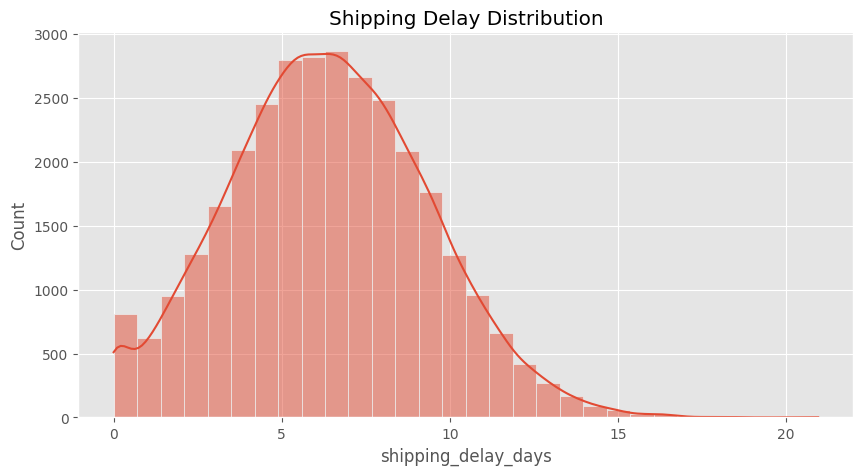

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['shipping_delay_days'],
    kde=True,
    bins=30
)

plt.title(
    'Shipping Delay Distribution'
)

plt.show()

## Correlation Heatmap

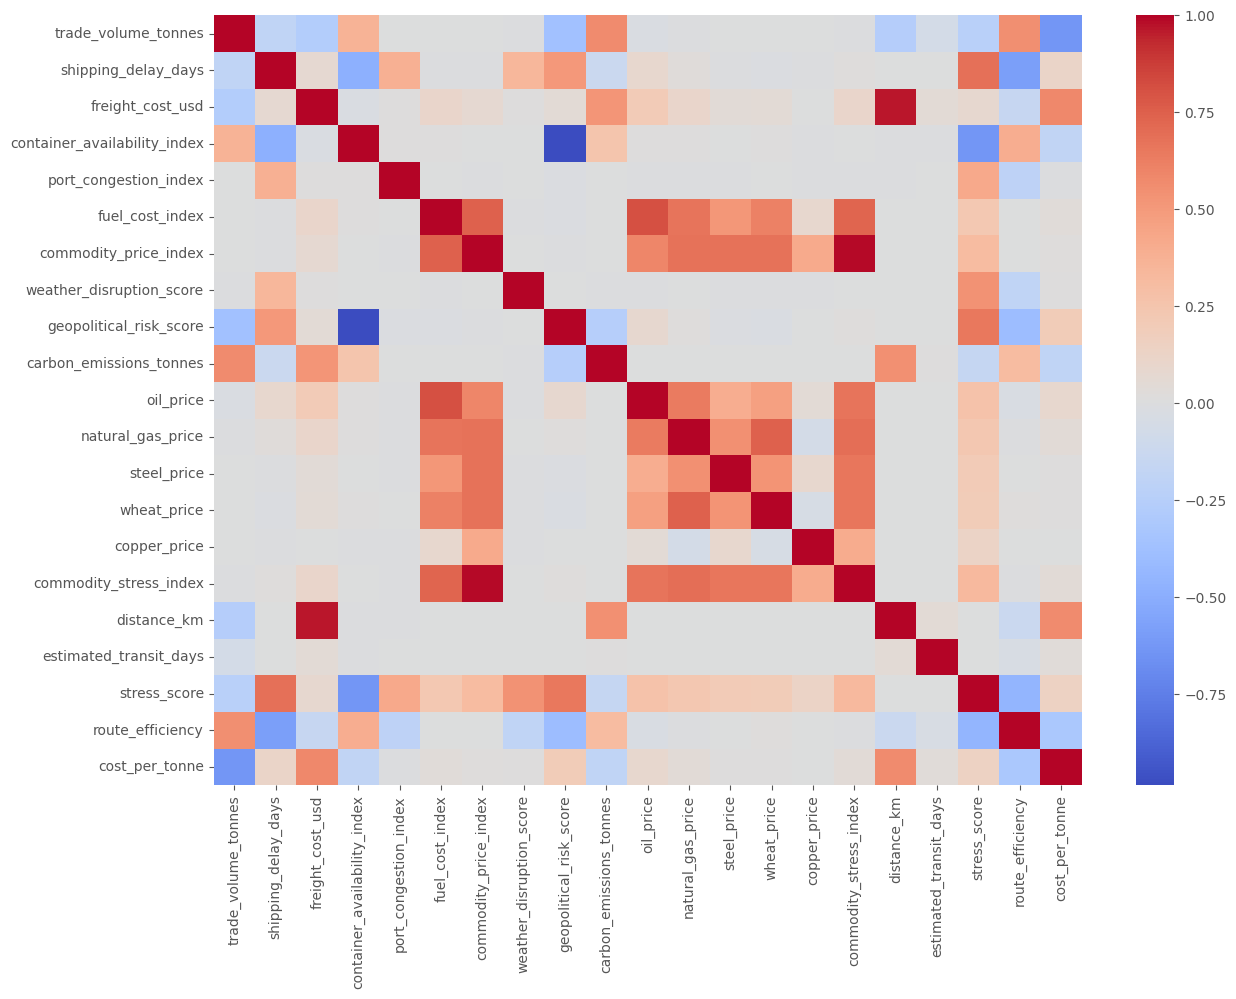

In [15]:
plt.figure(figsize=(14,10))

corr = df.select_dtypes(
    include=np.number
).corr()

sns.heatmap(
    corr,
    cmap='coolwarm'
)

plt.show()

## Risk vs Delay

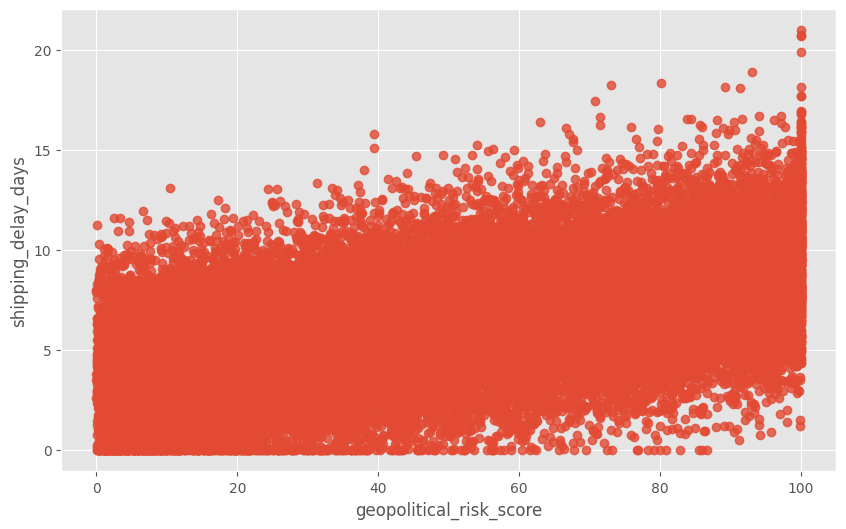

In [16]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='geopolitical_risk_score',
    y='shipping_delay_days'
)

plt.show()

# SECTION 9

## Delay Prediction

In [17]:
# target 

target = 'shipping_delay_days'

In [18]:
# features

features = [

'trade_volume_tonnes',
'freight_cost_usd',
'container_availability_index',
'port_congestion_index',
'fuel_cost_index',
'commodity_price_index',
'weather_disruption_score',
'geopolitical_risk_score',
'commodity_stress_index',
'stress_score',
'route_efficiency',
'cost_per_tonne'

]

In [19]:
# Train/Test

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## XGBoost

In [20]:
model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [21]:
## Predictions

preds = model.predict(
    X_test
)

In [22]:
## Evaluation

print(
    "MAE:",
    mean_absolute_error(y_test,preds)
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            preds
        )
    )
)

print(
    "R2:",
    r2_score(
        y_test,
        preds
    )
)

MAE: 0.09457555908747226
RMSE: 0.17948839308009534
R2: 0.9963114407782494


# SECTION 10
## SHAP Explainability

In [23]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(
    X_test
)

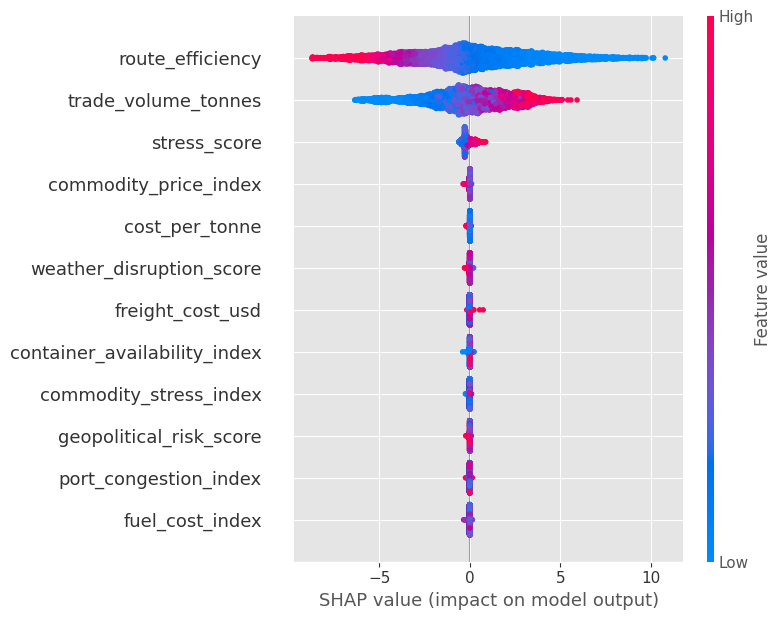

In [24]:
shap.summary_plot(
    shap_values,
    X_test
)

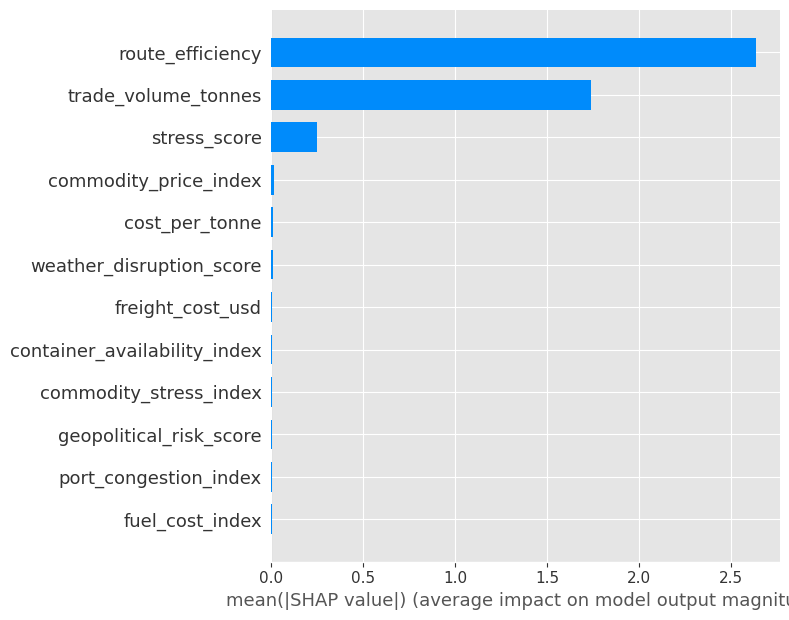

In [25]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

# SECTION 11

## Anomaly Detection

In [26]:
anomaly_features = [

'shipping_delay_days',
'freight_cost_usd',
'trade_volume_tonnes',
'stress_score'

]

In [27]:
iso = IsolationForest(
    contamination=0.02,
    random_state=42
)

In [28]:
df['anomaly'] = iso.fit_predict(
    df[anomaly_features]
)

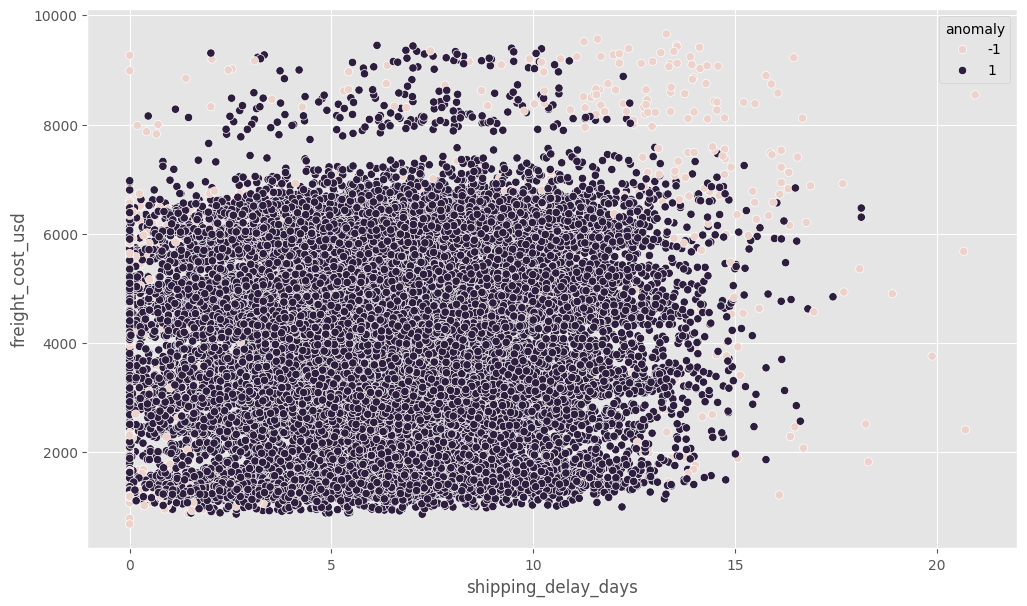

In [29]:
plt.figure(figsize=(12,7))

sns.scatterplot(
    data=df,
    x='shipping_delay_days',
    y='freight_cost_usd',
    hue='anomaly'
)

plt.show()

# SECTION 12

## Trade Route Clustering

In [30]:
# Aggregate routes

route_df = (
    df.groupby(
        'route_id'
    )
    .agg({
        'shipping_delay_days':'mean',
        'freight_cost_usd':'mean',
        'stress_score':'mean',
        'trade_volume_tonnes':'mean'
    })
)

In [31]:
# Scale

scaler = StandardScaler()

scaled = scaler.fit_transform(
    route_df
)

In [32]:
# KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

route_df['cluster'] = (
    kmeans.fit_predict(
        scaled
    )
)

In [33]:
# PCA

pca = PCA(
    n_components=2
)

coords = pca.fit_transform(
    scaled
)

route_df['PC1'] = coords[:,0]
route_df['PC2'] = coords[:,1]

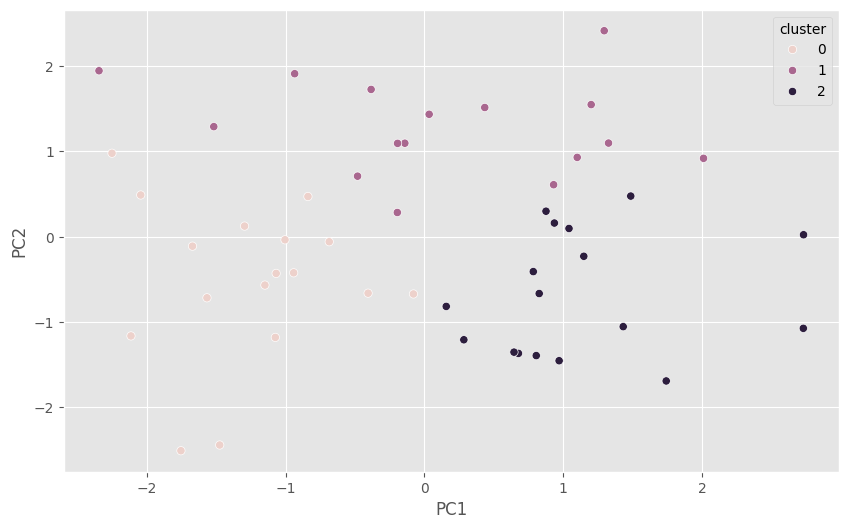

In [34]:
# Visualization

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=route_df,
    x='PC1',
    y='PC2',
    hue='cluster'
)

plt.show()

# SECTION 13

## Forecast Supply Chain Stress

In [35]:
from prophet import Prophet

In [36]:
forecast_df = commodity[
    ['date',
     'commodity_stress_index']
]

In [37]:
forecast_df.columns = [
    'ds',
    'y'
]

In [38]:
model_prophet = Prophet()

model_prophet.fit(
    forecast_df
)

01:38:07 - cmdstanpy - INFO - Chain [1] start processing
01:38:07 - cmdstanpy - INFO - Chain [1] done processing


In [39]:
future = model_prophet.make_future_dataframe(
    periods=52,
    freq='W'
)

In [40]:
forecast = model_prophet.predict(
    future
)

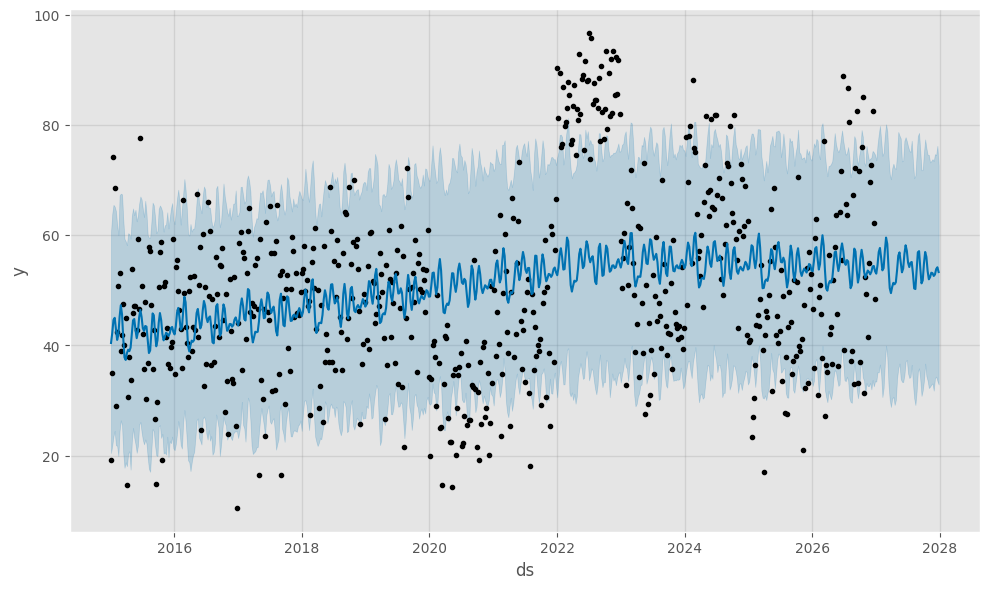

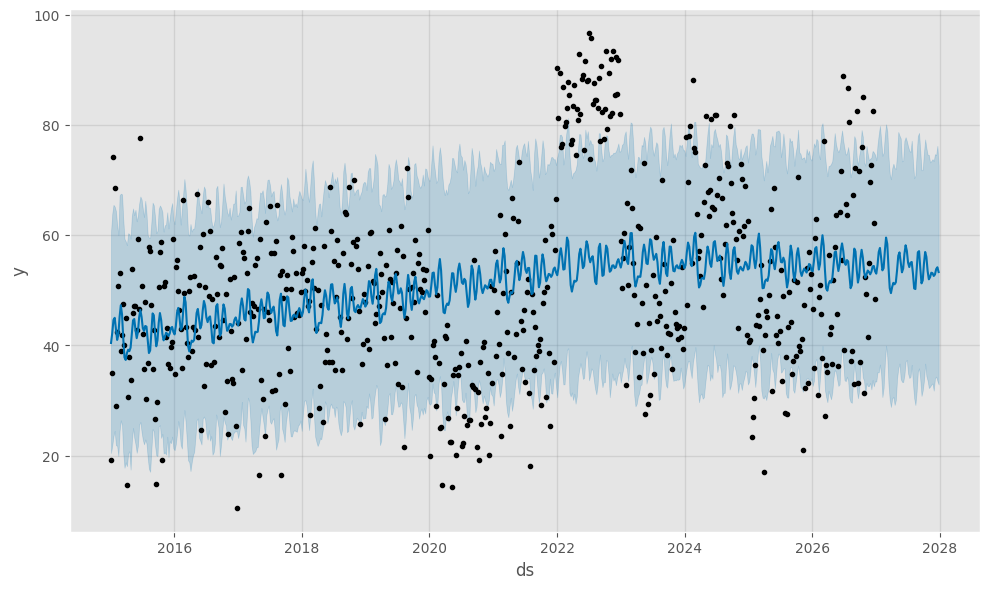

In [41]:
model_prophet.plot(
    forecast
)

# SECTION 14
## Executive Dashboard

In [42]:
# KPIs

kpis = {

"Average Delay":
df['shipping_delay_days'].mean(),

"Average Freight Cost":
df['freight_cost_usd'].mean(),

"Average Risk":
df['geopolitical_risk_score'].mean(),

"Average Volume":
df['trade_volume_tonnes'].mean()

}

pd.DataFrame(
    kpis.items(),
    columns=[
        "Metric",
        "Value"
    ]
)

,Metric,Value
0,Average Delay,6.381002
1,Average Freight Cost,4058.009023
2,Average Risk,50.957961
3,Average Volume,18823.910606


## Top Risk Routes

In [43]:
top_routes = (
    df.groupby(
        'route_id'
    )['stress_score']
      .mean()
      .sort_values(
          ascending=False
      )
      .head(10)
)

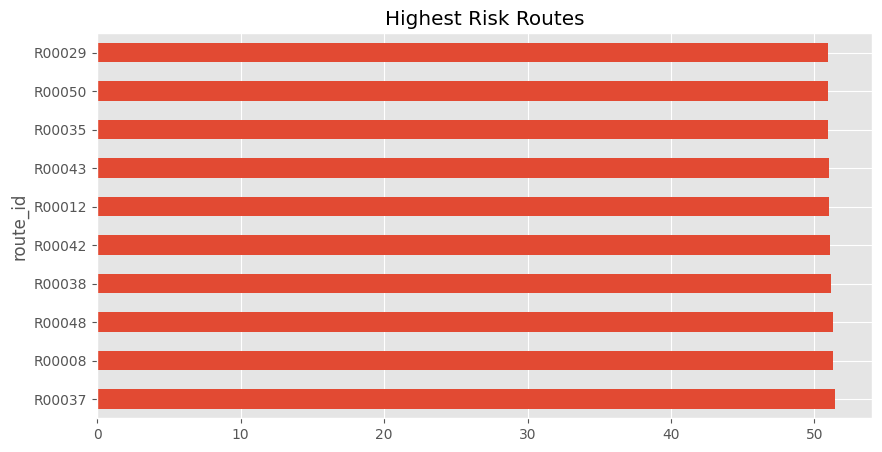

In [44]:
top_routes.plot(
    kind='barh',
    figsize=(10,5)
)

plt.title(
    "Highest Risk Routes"
)

plt.show()

# SECTION 15

## Key Business Insights

1. Geopolitical risk is the strongest driver of delays.

2. Port congestion significantly impacts freight costs.

3. High stress-score routes consistently experience longer delays.

4. Anomaly detection reveals rare disruption events.

5. Trade routes naturally separate into stable and high-risk groups.

6. Commodity stress trends indicate future supply chain pressure.

# SECTION 16

## Conclusion

This notebook demonstrated how machine learning can transform supply chain analytics.

We:

✔ Predicted delays using XGBoost

✔ Explained predictions using SHAP

✔ Detected unusual disruptions

✔ Clustered trade routes

✔ Forecasted future stress conditions

These techniques can help logistics companies improve resilience, reduce operational risk, and make better strategic decisions.